In [62]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn import datasets
from src import nn

---

## *Module*

In [41]:
class Module():

    def __call__(self, *args):
        self.out = self.forward(*args)
        return self.out

    def forward(self):
        raise NotImplementedError()

    def backward(self):
        return NotImplementedError()

## *Linear Layer*

In [42]:
class Linear(Module):
    
    def __init__(self, n_in, n_out, trainable=True):
        self.trainable = trainable
        self.weights = np.random.randn(n_in, n_out) 
        self.bias = np.zeros(n_out)
    
    def forward(self, x):
        self.inp = x
        return x @ self.weights + self.bias
    
    def backward(self, out_grad):
        self.weights_grad = self.inp.T @ out_grad
        self.bias_grad = out_grad.sum(axis=0)
        return out_grad @ self.weights.T

    def update(self, lr):
        self.weights -= lr * self.weights_grad
        self.bias -= lr * self.bias_grad

## *Activation Layers*

In [43]:
class Relu(Module):
    
    def forward(self, x):
        self.inp = x
        return np.maximum(self.inp, 0)
    
    def backward(self, out_grad):
        return (self.inp > 0).astype(float) * out_grad


class Sigmoid(Module):

    def forward(self, x):
        self.inp = x
        return 1 / (1 + np.exp(-self.inp))

    def backward(self, out_grad):
        return self.out * (1 - self.out) * out_grad


class Tanh(Module):

    def forward(self, x):
        self.inp = x
        return (np.exp(self.inp) - np.exp(-self.inp)) / (np.exp(self.inp) + np.exp(-self.inp))

    def backward(self, out_grad):
        return (1 - self.out ** 2) * out_grad

## *Loss Functions*

In [44]:
class MSE(Module): 
    
    def forward(self, pred, targ):
        self.pred = pred
        self.targ = targ
        return ((self.pred - self.targ)**2).mean()
    
    def backward(self):
        return 2 * (self.pred - self.targ) / self.targ.shape[0]


class Cross_Entropy(Module): 

    def forward(self, pred, targ):
        pred = np.exp(pred - np.max(pred, axis=1, keepdims=True))
        self.probs = pred / np.sum(pred, axis=1, keepdims=True)
        self.targ = targ
        return -np.log(self.probs[range(self.targ.shape[0]), self.targ].mean())

    def backward(self):
        self.probs[range(self.targ.shape[0]), self.targ] -= 1
        return self.probs / self.targ.shape[0]

## *Model / Network*

In [50]:
class Model_Num(): # Model = Network
    
    def __init__(self, n_inp, n_hidden, n_out):
        self.layers = [Linear(n_inp, n_hidden),    Tanh(), 
                       Linear(n_hidden, n_hidden), Tanh(),
                       Linear(n_hidden, n_out)]
        self.loss_fn = MSE()
    
    def forward(self, x, targ):
        for layer in self.layers:
            x = layer(x)

        loss = self.loss_fn(x, targ)
        pred = x
        return loss, pred
    
    def backward(self):
        out_grad = self.loss_fn.backward()
        for layer in reversed(self.layers):
            out_grad = layer.backward(out_grad)

    def step(self, lr):
        for layer in self.layers:
            if hasattr(layer, 'trainable'):
                if layer.trainable:
                    layer.update(lr)

########################################################################

class Model_Cat(): # Model = Network
    
    def __init__(self, n_inp, n_hidden, n_out):
        self.layers = [Linear(n_inp, n_hidden),    Relu(), 
                       Linear(n_hidden, n_hidden), Relu(),
                       Linear(n_hidden, n_out)]
        self.loss_fn = Cross_Entropy()
    
    def forward(self, x, targ):
        for layer in self.layers:
            x = layer(x)

        loss = self.loss_fn(x, targ)
        pred = self.loss_fn.probs.argmax(axis=1)
        return loss, pred
    
    def backward(self):
        out_grad = self.loss_fn.backward()
        for layer in reversed(self.layers):
            out_grad = layer.backward(out_grad)

    def step(self, lr):
        for layer in self.layers:
            if hasattr(layer, 'trainable'):
                if layer.trainable:
                    layer.update(lr)

## *Plots & Metrics*

In [51]:
def plot_loss(loss_history):
    plt.plot(loss_history)
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Loss Curve')
    plt.show()

def plot_accuracy(pred, x, y):
    plt.plot(x, y, label='True', ls='--')
    plt.plot(x, pred, label='Prediction')
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title('Model vs True')
    plt.legend()
    plt.show()

def get_accuracy(pred, y):
    correct = np.sum(pred == y)
    accuracy = correct / y.shape[0]
    return accuracy
    

## *Training*

In [52]:
def fit(model, x, y, epochs, lr, verbose=True, cat=True):
    loss_history = []
    acc_history = []
    pred_initial, _ = model.forward(x, y)
    
    for epoch in range(epochs):
        loss, pred = model.forward(x, y)
        acc = get_accuracy(pred, y)
        model.backward()
        model.step(lr)
        
        if epoch % 500 == 0 and verbose:
            if cat:
                print(f'Epoch: {epoch:4} | Loss: {loss:.4f} | Accuracy: {100*acc:.2f}')
            else:
                print(f'Epoch: {epoch:4} | Loss: {loss:.4f}')
               
        loss_history.append(loss)
        acc_history.append(acc)
    
    return loss_history, acc_history, pred, pred_initial

## *Numeric Data*

In [53]:
np.random.seed(1337)
x = np.linspace(-10, 10, 400).reshape(-1, 1)
y = np.sin(x)

mn = Model_Num(n_inp=1, n_hidden=16, n_out=1)

Epoch:    0 | Loss: 0.9196
Epoch:  500 | Loss: 0.2070
Epoch: 1000 | Loss: 0.1984
Epoch: 1500 | Loss: 0.1912
Epoch: 2000 | Loss: 0.1853
Epoch: 2500 | Loss: 0.1803
Epoch: 3000 | Loss: 0.1758
Epoch: 3500 | Loss: 0.1719
Epoch: 4000 | Loss: 0.1683
Epoch: 4500 | Loss: 0.1651


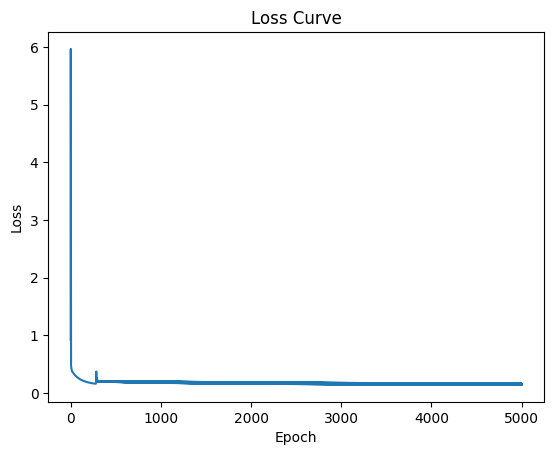

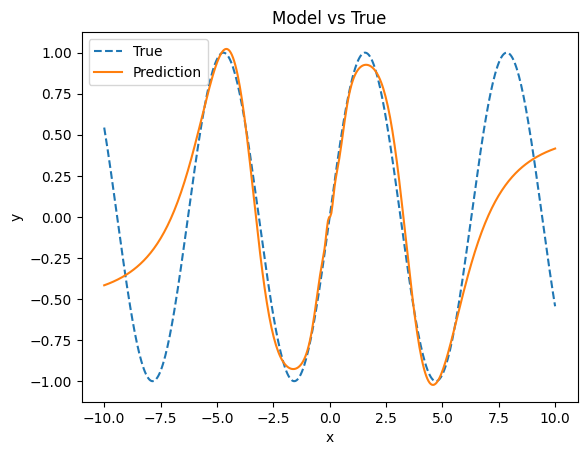

In [54]:
loss_history, acc_history, pred, _ = fit(mn, x, y, 5000, 0.03, cat=False)
plot_loss(loss_history)
plot_accuracy(pred, x, y)

## *Categorical Data*

In [55]:
np.random.seed(1337)
iris = datasets.load_iris()
x = iris.data
y = iris.target

mc = Model_Cat(4, 16, 3)

Epoch:    0 | Loss: 1.0986 | Accuracy: 33.33
Epoch:  500 | Loss: 0.0670 | Accuracy: 96.67
Epoch: 1000 | Loss: 0.0577 | Accuracy: 96.67
Epoch: 1500 | Loss: 0.0530 | Accuracy: 96.67
Epoch: 2000 | Loss: 0.0499 | Accuracy: 96.67
Epoch: 2500 | Loss: 0.0478 | Accuracy: 96.67
Epoch: 3000 | Loss: 0.0462 | Accuracy: 96.00
Epoch: 3500 | Loss: 0.0449 | Accuracy: 96.67
Epoch: 4000 | Loss: 0.0438 | Accuracy: 97.33
Epoch: 4500 | Loss: 0.0429 | Accuracy: 97.33
Epoch: 5000 | Loss: 0.0421 | Accuracy: 97.33
Epoch: 5500 | Loss: 0.0414 | Accuracy: 97.33
Epoch: 6000 | Loss: 0.0408 | Accuracy: 97.33
Epoch: 6500 | Loss: 0.0402 | Accuracy: 97.33
Epoch: 7000 | Loss: 0.0397 | Accuracy: 97.33
Epoch: 7500 | Loss: 0.0392 | Accuracy: 97.33
Epoch: 8000 | Loss: 0.0388 | Accuracy: 97.33
Epoch: 8500 | Loss: 0.0384 | Accuracy: 97.33
Epoch: 9000 | Loss: 0.0380 | Accuracy: 97.33
Epoch: 9500 | Loss: 0.0377 | Accuracy: 98.00


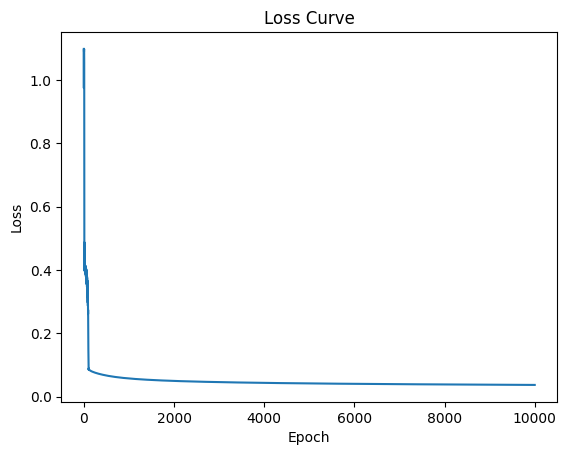

In [56]:
loss_history, acc_history, pred, pred_initial = fit(mc, x, y, 10000, 0.003)
plot_loss(loss_history)

----

In [57]:
act_fn = 'Relu'
num_neurons = [4, 16, 16, 16, 16, 3]

layers = []
for i, (n_in, n_out) in enumerate(zip(num_neurons, num_neurons[1:])):
    if n_out != num_neurons[-1]:
        layers.extend([Linear(n_in, n_out), eval(act_fn+'()')])
        
    else:
        layers.append(Linear(n_in, n_out))        

In [58]:
layers

In [69]:
print(vars(args))

TypeError: vars() argument must have __dict__ attribute